In [1]:
from typing import Dict, List

from model_ranking import (
    get_summary_results,
    per_source_model_results,
    per_target_consis_result_type,
    per_target_performance_result_type,
    cmb_consistency_score_weighted_average,
    to_target_transfer_correlations,
    correlation_table,
    to_target_transfer_correlations_with_norm,
    plot_alpha_sweep_specific_norm,
)

INFO: P [MainThread] 2026-02-23 10:23:31,647 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_mapping = {
    "FlyWing": "fw",
    "Ovules": "ov",
    "PNAS": "p",
}
consis_keys={
    "FlyWing": "AdaRandError_consis",
    "Ovules": "AdaRandError_consis",
    "PNAS": "AdaRandError_consis",
}
# consis_keys_bckg = {
#     "EPFL": "EI_consis_bckg",
#     "Hmito": "EI_consis_bckg",
#     "Rmito": "EI_consis_bckg",
#     "VNC": "EI_consis_bckg",
# }

In [3]:
result_folders_StoT={
    "FlyWing": "predictions",
    "Ovules": "predictions",
    "PNAS": "predictions",
}

per_target_norms_StoT: Dict[str, List[None]] = {
    "FlyWing": [None],
    "Ovules": [None],
    "PNAS": [None],
}

perf_key_StoT = "MAP_05_095"
approach_StoT = None
base_result_path_StoT = "/g/kreshuk/talks/model_ranking_results/AdaptiveBatchNorm/Cells/train_mode_stats"

In [4]:
result_folders_StoS={
    "FlyWing": "finetuned_fullslice",
    "Ovules": "finetuned_fullslice",
    "PNAS": "finetuned_fullslice",
}

per_target_norms_StoS: Dict[str, List[None]] = {
    "FlyWing": [None],
    "Ovules": [None],
    "PNAS": [None],
}

perf_key_StoS = "MAP_05_095"
approach_StoS = "consistency"
base_result_path_StoS = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells"

In [7]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    "gauss": ["a001-005", "a005-01", "a01-015", "a015-02", "a02-025"],
}   
consis_postfix="median"
perf_postfix="median"
targets = ["FlyWing", "Ovules", "PNAS"]
#targets = ["EPFL"]
sources = ["FlyWing", "Ovules", "PNAS"]
#sources = ["Hmito"]

In [15]:
model_set: Dict[str, List[str]] = {
    # "fwtofw": ["fwtofw_model_Res2", "fwtofw_model_Unet2"],
    "fwtoov": ["fwtoov_model_Res2", "fwtoov_model_Unet2"],
    "fwtop": ["fwtop_model_Res2", "fwtop_model_Unet2"],
    "ovtofw": ["ovtofw_model_Res1", "ovtofw_model_UNet1", "ovtofw_model_NA1"],
    # "ovtoov": ["ovtoov_model_Res1", "ovtoov_model_UNet1", "ovtoov_model_NA1"],
    "ovtop": ["ovtop_model_Res1", "ovtop_model_UNet1", "ovtop_model_NA1"],
    "ptofw": ["ptofw_model_Res1", "ptofw_model_UNet1", "ptofw_model_NA1"],
    "ptoov": ["ptoov_model_Res1", "ptoov_model_UNet1", "ptoov_model_NA1"],
    # "ptop": ["ptop_model_Res1", "ptop_model_UNet1", "ptop_model_NA1"],
}

In [16]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
for i, target in enumerate(targets):
    per_source_forg_consistency = {}
    per_source_forg_performance = {}
    for source in sources:
        transfer = f"{data_mapping[source]}to{data_mapping[target]}"
        if transfer not in model_set:
            continue
        
        # if source == target:
        #     base_result_path = base_result_path_StoS
        #     result_folders = result_folders_StoS
        #     per_target_norms = per_target_norms_StoS
        #     perf_key = perf_key_StoS
        #     approach = approach_StoS
        # else:
        base_result_path = base_result_path_StoT
        result_folders = result_folders_StoT
        per_target_norms = per_target_norms_StoT
        perf_key = perf_key_StoT
        approach = approach_StoT

        for model in model_set[transfer]:
            consis_str, _, NA_perf = get_summary_results(
                source_data=[source],
                target_data=[target],
                selected_augmentations=selected_augmentations,
                consis_keys=consis_keys,
                result_folders=result_folders,
                source_models={source: model},
                selected_norms=per_target_norms,
                perf_key=perf_key,
                per_target_norms=True,
                approach=approach,
                consis_postfix=consis_postfix,
                perf_postfix=perf_postfix,
                summary_results_postfix=summary_results_postfix,
                base_seg_dir=base_result_path,
            )
            per_source_forg_consistency.update(
                per_source_model_results(
                    consis_str, 
                    source_models={source: model}, 
                ))
            per_source_forg_performance.update(
                per_source_model_results(
                    NA_perf, 
                    source_models={source: model},
                ))
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: Ovules


100%|██████████| 1/1 [00:00<00:00, 33.43it/s]


Source: Ovules


100%|██████████| 1/1 [00:00<00:00, 36.42it/s]


Source: Ovules


...

100%|██████████| 1/1 [00:00<00:00, 42.10it/s]


Source: Ovules


100%|██████████| 1/1 [00:00<00:00, 38.22it/s]


Source: Ovules


100%|██████████| 1/1 [00:00<00:00, 41.82it/s]


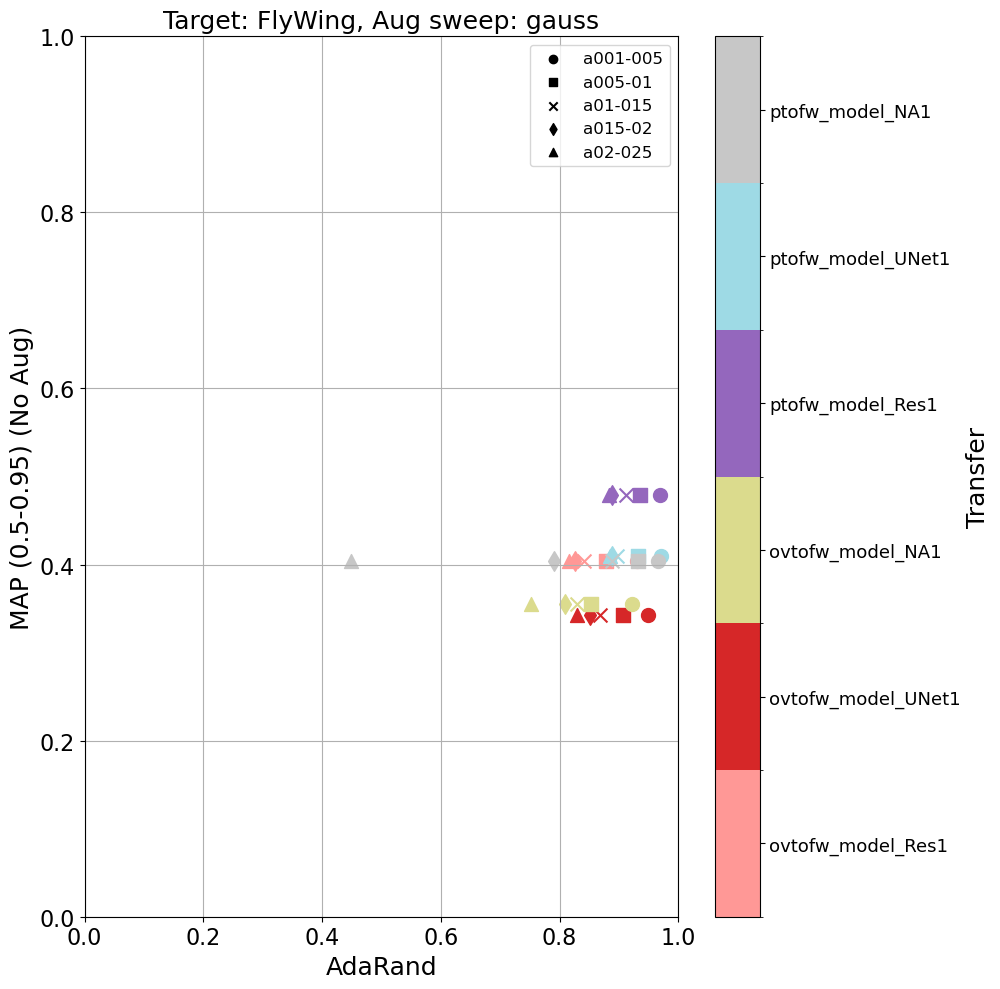

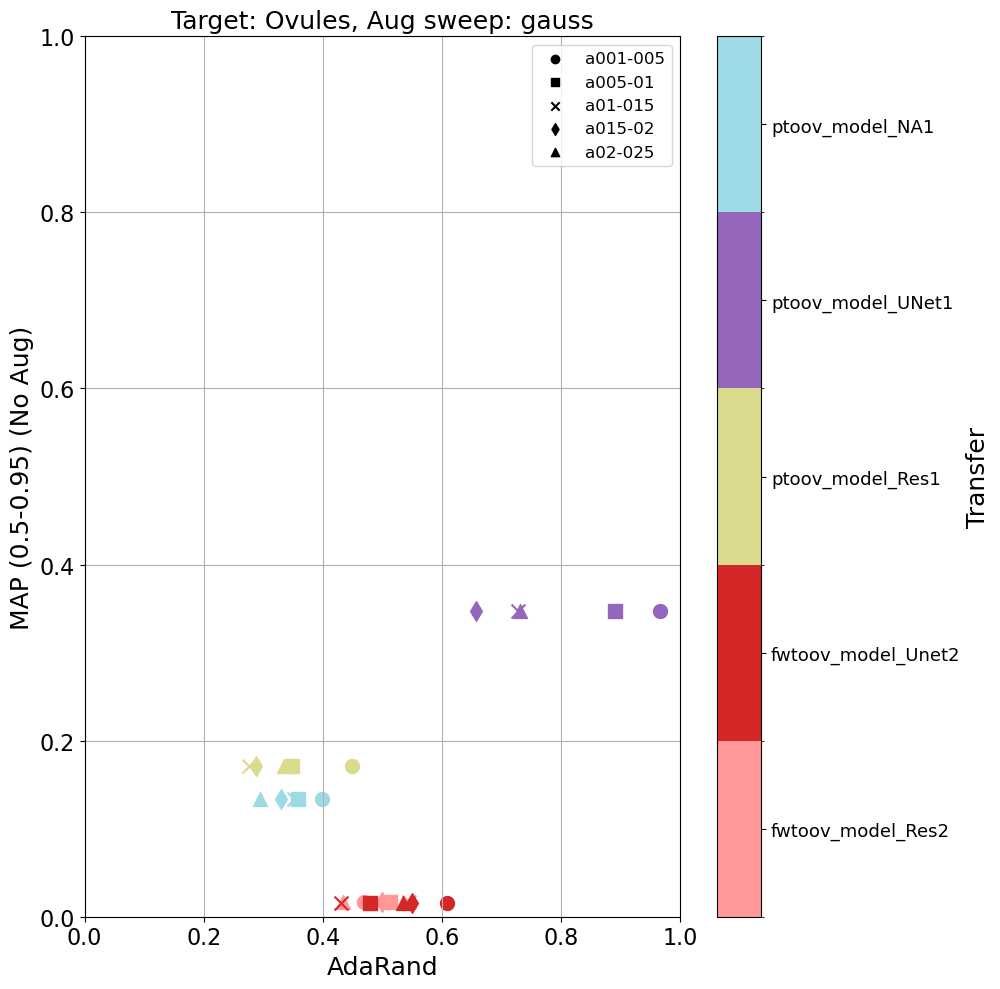

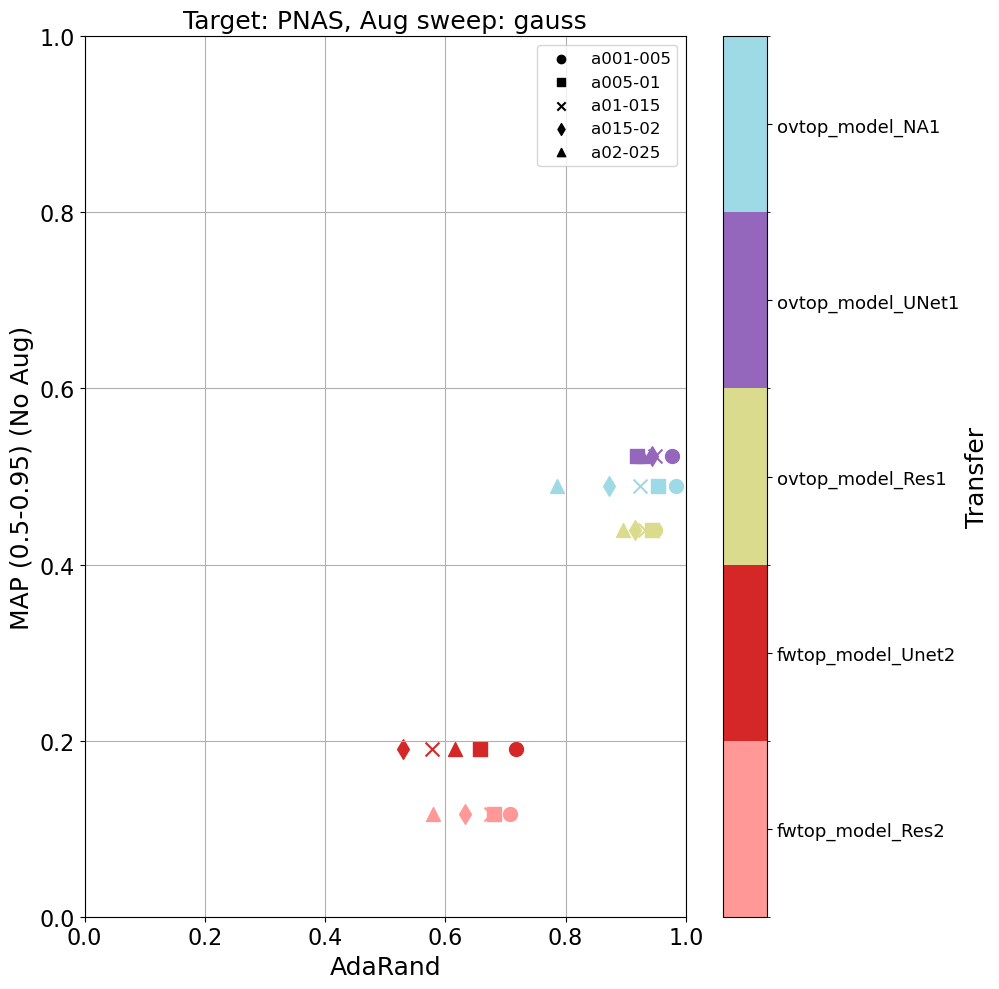

In [17]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="AdaRand",
        transfer_metric_name="MAP (0.5-0.95)",
        invert_consis_metric= True,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

In [18]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_forg_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
    perturbation_key="gauss",
    invert_consis_score=True,
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

gauss: a001-005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.47     0.27   0.66        0.21  0.59     0.22
     Ovules   0.00     1.00   0.10        0.95  0.69     0.19
     PNAS     0.80     0.08   0.90        0.10  0.99     0.00
gauss: a005-01
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito FlyWing  0.6     0.15   0.71        0.17  0.59     0.22
     Ovules   0.0     1.00   0.10        0.96  0.65     0.24
     PNAS     0.4     0.46   0.60        0.42  0.96     0.01
gauss: a01-015
               kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                
Mito FlyWing  0.6     0.11   0.71        0.13  0.69     0.13
     Ovules   0.0     1.00   0.10        0.92  0.45     0.44
     PNAS     0.6     0.23   0.80        0.14  0.93     0.02
gauss: a015-02
                kt 

# Save Results

In [19]:
per_target_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_performance[target] = {}
    for model, performance in per_model_performance.items():
        if isinstance(performance, dict):
            per_target_performance[target][model] = performance['norm_Normalize']
        else:
            per_target_performance[target][model] = performance

In [21]:
import json
import os
from typing import Any
from model_ranking.results import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/AdaBN"
if not os.path.exists(save_path):
    os.makedirs(save_path)

# for i, alpha in enumerate(selected_augmentations['gauss']):
#     per_target_consistency: Dict[str, Dict[str,float]] = {}
#     for target, per_model_consistency in per_target_forg_consistency.items():
#         per_target_consistency[target] = {}
#         for model, consistency in per_model_consistency.items():
#             per_target_consistency[target][model] = consistency['norm_Normalize']['gauss'][i]

#     with open(os.path.join(save_path, f"transfer_AdaBN_Gauss_{alpha}_FORG_ARE_scores.json"), "w") as f:
#         results: Dict[str, Any] = {
#             "transfer_scores": convert_numpy_types(per_target_consistency),
#         }
#         json.dump(results, f, indent=4)


with open(os.path.join(save_path, f"transfer_performance_AdaBN_MAP_scores.json"), "w") as f:
    results: Dict[str, Any] = {
        "performance_scores": convert_numpy_types(per_target_performance),
    }
    json.dump(results, f, indent=4)